In [1]:
import pandas as pd

In [2]:
BTC_data = pd.read_csv('/Users/yitik/Desktop/Dersler/For Python/InvestGuide/investment_ml/rawData/BTC_rawDataset.csv')
df = BTC_data.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1838 entries, 0 to 1837
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tarih   1838 non-null   object
 1   Deger   1838 non-null   object
dtypes: object(2)
memory usage: 28.8+ KB


In [5]:
df.head()

,Tarih,Deger
0,8 Aralık 2020,$18.337
1,9 Aralık 2020,$18.565
2,10 Aralık 2020,$18.262
3,11 Aralık 2020,$18.058
4,12 Aralık 2020,$18.807


In [7]:
aylar = {
    'Ocak': '01', 'Şubat': '02', 'Mart': '03', 'Nisan': '04', 'Mayıs': '05', 'Haziran': '06',
    'Temmuz': '07', 'Ağustos': '08', 'Eylül': '09', 'Ekim': '10', 'Kasım': '11', 'Aralık': '12'
}

# Tarih sütunundaki ay isimlerini değiştirme
for tr, num in aylar.items():
    df['Tarih'] = df['Tarih'].str.replace(tr, num, regex=False)

# 2. Datetime formatına çevirme (Gün Ay Yıl formatında olduğu için dayfirst=True)
# Artık format "15 10 2021" gibi oldu, bunu datetime'a çeviriyoruz.
df['Tarih'] = pd.to_datetime(df['Tarih'], format='%d %m %Y')

# 3. Kronolojik Sıralama (Zaman serisi için çok kritiktir!)
df = df.sort_values('Tarih').reset_index(drop=True)

print(df.info())

ValueError: time data "
              
                Bitcoin
              
            " doesn't match format "%d %m %Y", at position 1828. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [9]:
print(df[df.Tarih == """
              
                Bitcoin
              
            """])

                                                  Tarih    Deger
1828  \n              \n                Bitcoin\n   ...  $90.670


In [11]:
df.loc[1820:1835, :]

,Tarih,Deger
1820,1 12 2025,$85.510
1821,2 12 2025,$90.990
1822,3 12 2025,$92.925
1823,4 12 2025,$92.516
1824,5 12 2025,$89.309
1825,6 12 2025,$89.549
1826,7 12 2025,$91.450
1827,8 12 2025,$90.900
1828,\n \n Bitcoin\n ...,$90.670
1829,\n \n Ethereum\n ...,"$3.128,19"


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1838 entries, 0 to 1837
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tarih   1838 non-null   object
 1   Deger   1838 non-null   object
dtypes: object(2)
memory usage: 28.8+ KB


In [15]:
df.loc[1828::]

,Tarih,Deger
1828,\n \n Bitcoin\n ...,$90.670
1829,\n \n Ethereum\n ...,"$3.128,19"
1830,\n \n Ripple\n ...,"$2,0857"
1831,\n \n Litecoin\n ...,"$83,66"
1832,\n \n Euro Amerika...,"1,1640"
1833,\n \n Dolar Endeks...,"99,0500"
1834,\n \n Brent Petrol...,"$62,32"
1835,\n \n TR 2 Yıllık ...,"38,09"
1836,\n \n Döviz Sepeti...,"46,0950"
1837,\n \n BIST 100\n ...,"11.189,50"


Anlaşılan veriyi kazırken burada ufak bir hata olmuş ve sekiz aralık sonrasında da bunları kazımış. Zaten ben veriyi de sekiz aralığa kadar çekmiştim. Problem görünmüyor. Bunu kaldırıp devam edicem.

In [17]:
df = df.loc[:1827]
df.tail()

,Tarih,Deger
1823,4 12 2025,$92.516
1824,5 12 2025,$89.309
1825,6 12 2025,$89.549
1826,7 12 2025,$91.450
1827,8 12 2025,$90.900


Tamam artık devam edebiliriz.

In [19]:
df['Tarih'] = pd.to_datetime(df['Tarih'], format='%d %m %Y')

# 3. Kronolojik Sıralama (Zaman serisi için çok kritiktir!)
df = df.sort_values('Tarih').reset_index(drop=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1828 entries, 0 to 1827
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Tarih   1828 non-null   datetime64[ns]
 1   Deger   1828 non-null   object        
dtypes: datetime64[ns](1), object(1)
memory usage: 28.7+ KB
None


In [21]:
def ml_icin_hazirla(df):
    # Tarihi parçalarına ayırıyoruz ki model (Random Forest vb.) anlayabilsin
    df['Yil'] = df['Tarih'].dt.year
    df['Ay'] = df['Tarih'].dt.month
    df['Gun'] = df['Tarih'].dt.day
    df['HaftaninGunu'] = df['Tarih'].dt.dayofweek # 0: Pzt, 6: Paz
    
    # İPUCU: Finans verisinde "Lag" (Gecikmeli) özellikler model başarısını çok artırır.
    # "Bugünün fiyatını tahmin etmek için dünün kapanış fiyatını kullan" mantığı.
    df['Dunku_Deger'] = df['Deger'].shift(1)
    
    # İlk satırda "dün" olmadığı için NaN oluşur, siliyoruz
    df = df.dropna(inplace = True)
    
    return df
ml_icin_hazirla(df)

In [23]:
df.head()

,Tarih,Deger,Yil,Ay,Gun,HaftaninGunu,Dunku_Deger
1,2020-12-09,$18.565,2020,12,9,2,$18.337
2,2020-12-10,$18.262,2020,12,10,3,$18.565
3,2020-12-11,$18.058,2020,12,11,4,$18.262
4,2020-12-12,$18.807,2020,12,12,5,$18.058
5,2020-12-13,$19.151,2020,12,13,6,$18.807


In [29]:
df['Deger'].apply(lambda x: x[1:]) #kontrol için

1       18.565
2       18.262
3       18.058
4       18.807
5       19.151
         ...  
1823    92.516
1824    89.309
1825    89.549
1826    91.450
1827    90.900
Name: Deger, Length: 1827, dtype: object

In [25]:
df['Deger'] = df['Deger'].apply(lambda x: float(x[1:]))
df.head()

,Tarih,Deger,Yil,Ay,Gun,HaftaninGunu,Dunku_Deger
1,2020-12-09,18.565,2020,12,9,2,$18.337
2,2020-12-10,18.262,2020,12,10,3,$18.565
3,2020-12-11,18.058,2020,12,11,4,$18.262
4,2020-12-12,18.807,2020,12,12,5,$18.058
5,2020-12-13,19.151,2020,12,13,6,$18.807


In [27]:
df['Dunku_Deger'] = df['Dunku_Deger'].apply(lambda x: float(x[1:]))
df.head()

,Tarih,Deger,Yil,Ay,Gun,HaftaninGunu,Dunku_Deger
1,2020-12-09,18.565,2020,12,9,2,18.337
2,2020-12-10,18.262,2020,12,10,3,18.565
3,2020-12-11,18.058,2020,12,11,4,18.262
4,2020-12-12,18.807,2020,12,12,5,18.058
5,2020-12-13,19.151,2020,12,13,6,18.807


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1827 entries, 1 to 1827
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Tarih         1827 non-null   datetime64[ns]
 1   Deger         1827 non-null   float64       
 2   Yil           1827 non-null   int32         
 3   Ay            1827 non-null   int32         
 4   Gun           1827 non-null   int32         
 5   HaftaninGunu  1827 non-null   int32         
 6   Dunku_Deger   1827 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int32(4)
memory usage: 85.6 KB


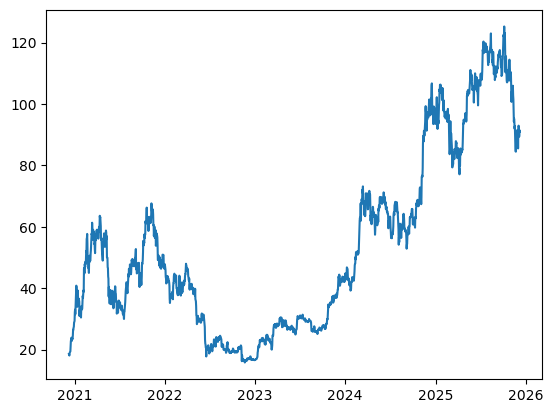

In [31]:
import matplotlib.pyplot as plt
plt.plot(df['Tarih'], df['Deger'])

In [43]:
df.set_index('Tarih').resample('M').mean()[['Deger']]

/var/folders/22/j5k7n31s4p1fkq4x0frr3myc0000gn/T/ipykernel_3403/728245877.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('Tarih').resample('M').mean()[['Deger']]


,Deger
Tarih,
2020-12-31,23.036739
2021-01-31,34.764710
2021-02-28,46.323179
2021-03-31,54.979387
2021-04-30,57.115300
...,...
2025-08-31,114.802677
2025-09-30,113.091400
2025-10-31,114.097452


In [47]:
df.head(1)

,Tarih,Deger,Yil,Ay,Gun,HaftaninGunu,Dunku_Deger
1,2020-12-09,18.565,2020,12,9,2,18.337


In [33]:
X = df.drop(columns = ['Tarih', 'Deger'])
y = df.Deger

In [35]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle= False)

In [39]:
print(f"Eğitim Verisi: {X_train.shape[0]} satır")
print(f"Test Verisi: {X_test.shape[0]} satır")

Eğitim Verisi: 1461 satır
Test Verisi: 366 satır


In [41]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, BayesianRidge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    # --- Temel Model ---
    "Linear Regression": LinearRegression(),
    
    # --- Regularization (Ceza) Ekleyen Modeller ---
    # Overfitting'i engeller, değişkenler arası korelasyonu (dolar vs euro gibi) yönetir.
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "ElasticNet": ElasticNet(random_state=42),
    
    # --- Gürültüye Dayanıklı (Robust) Modeller ---
    # Altın fiyatlarındaki ani iğne atışlarını (outlier) görmezden gelerek trendi yakalar.
    "Huber Regressor": HuberRegressor(max_iter=2000), # Yakınsama için iterasyonu artırdık
    "Bayesian Ridge": BayesianRidge(),
    
    # --- Ağaç Tabanlı Modeller (Kıyaslama için) ---
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
}

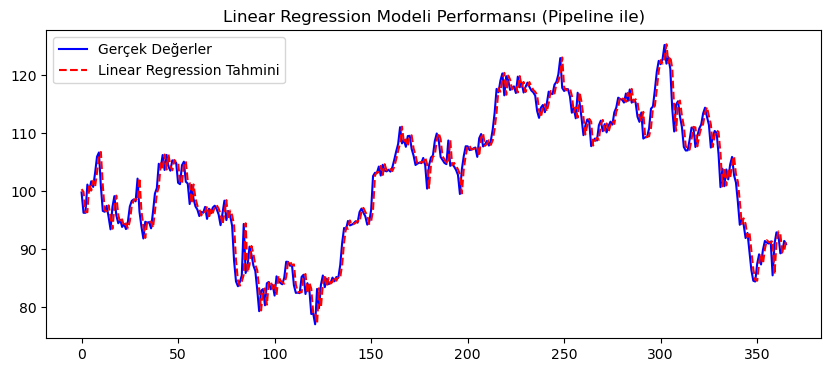

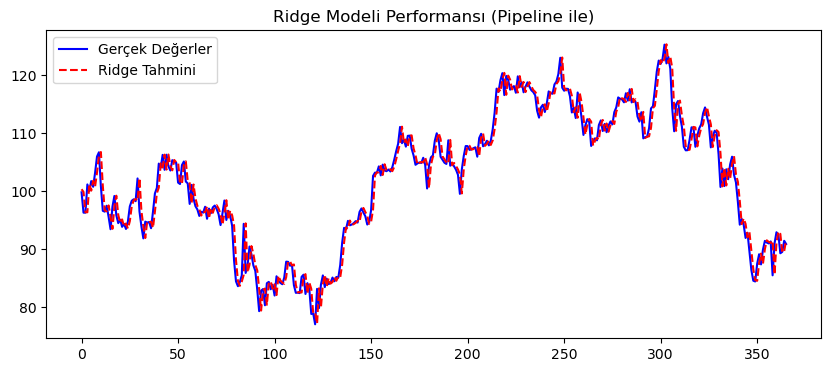

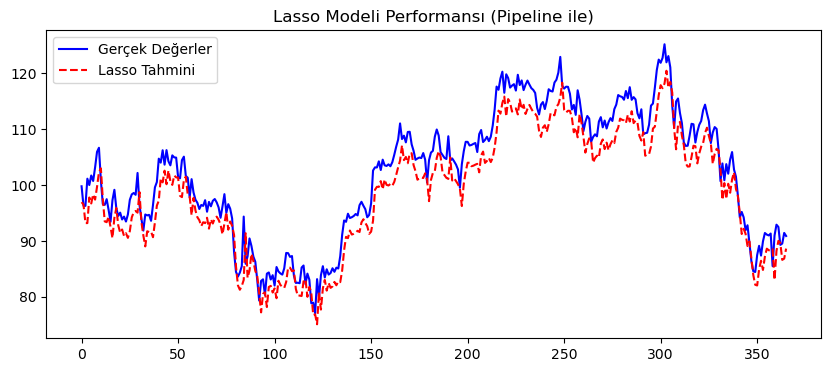

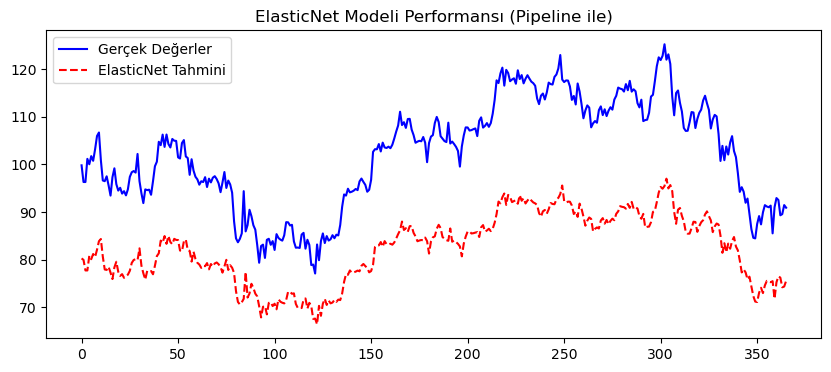

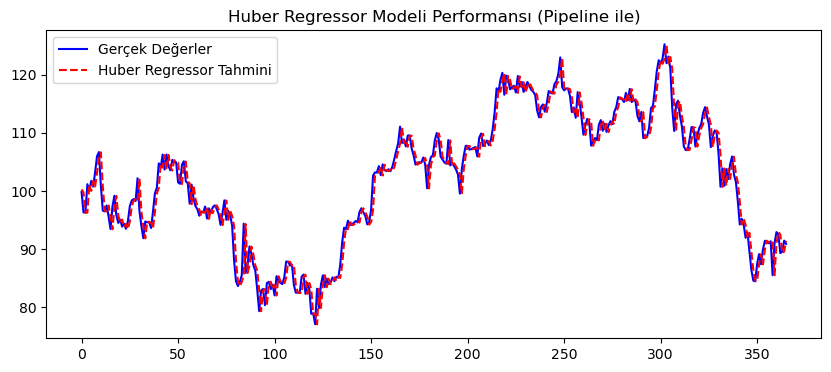

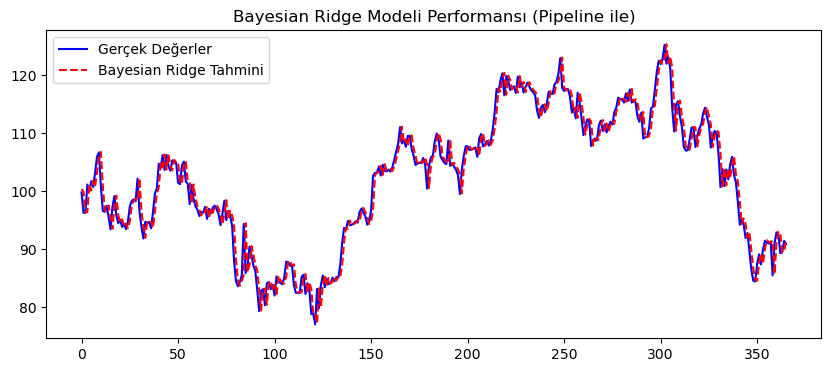

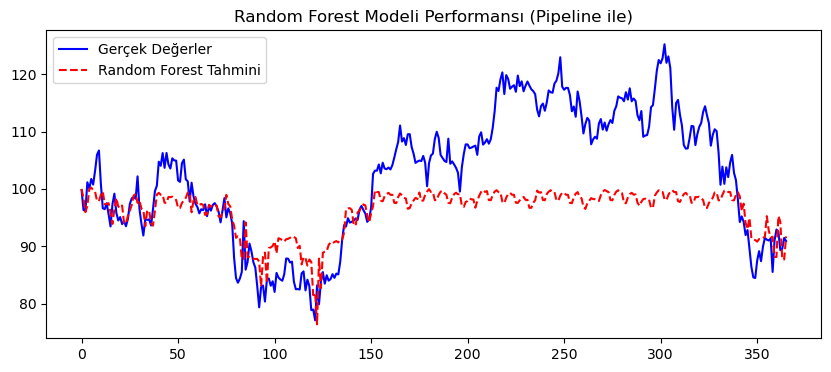

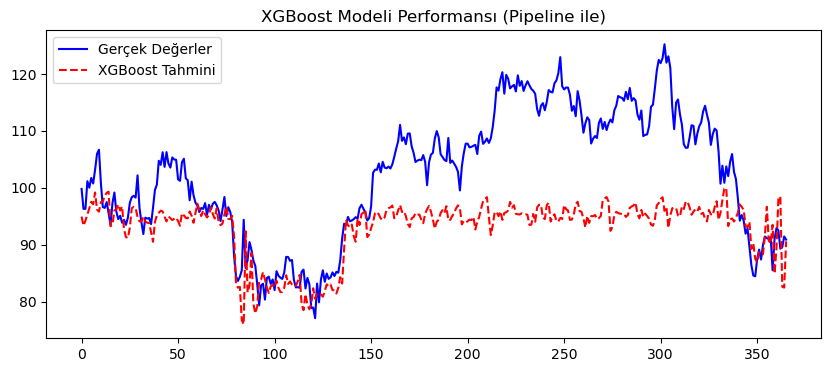

               Model  MAE (Ort. Hata TL)       RMSE  R2 Score (Başarı)
4    Huber Regressor            1.727600   2.261593           0.959583
1              Ridge            1.726744   2.263501           0.959515
5     Bayesian Ridge            1.727885   2.266028           0.959425
0  Linear Regression            1.727928   2.266124           0.959421
2              Lasso            3.586675   4.101623           0.867064
6      Random Forest            8.147014  10.398471           0.145580
7            XGBoost            9.836639  12.464088          -0.227589
3         ElasticNet           19.875152  20.372694          -2.279662


In [51]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler # Finans verisi için genelde bu kullanılır
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

results = []
best_score = -np.inf # En iyi skoru takip etmek için (R2'ye göre)
best_pipeline = None # En iyi modeli (pipeline halini) saklamak için
best_model_name = ""

# Döngü
for name, model in models.items():
    
    # --- DEĞİŞİKLİK BURADA BAŞLIYOR ---
    # 1. Pipeline Oluşturma: Önce veriyi Standartlaştır, sonra Modeli çalıştır.
    # Bu sayede 'scaler' sadece X_train istatistiklerini öğrenir, X_test'i buna göre dönüştürür.
    pipe = make_pipeline(StandardScaler(), model)
    
    # 2. Modeli Eğit (Pipeline üzerinden)
    pipe.fit(X_train, y_train)
    
    # 3. Tahmin Yap (Pipeline, X_test'i otomatik scale edip tahmin üretir)
    predictions = pipe.predict(X_test)
    # --- DEĞİŞİKLİK BURADA BİTİYOR ---

    # Metrikleri Hesapla
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    # Sonuçları listeye ekle
    results.append({
        "Model": name,
        "MAE (Ort. Hata TL)": mae,
        "RMSE": rmse,
        "R2 Score (Başarı)": r2
    })
    
    # En iyi modeli hafızada tut (R2 skoruna göre)
    if r2 > best_score:
        best_score = r2
        best_pipeline = pipe # Eğitilmiş pipeline'ı saklıyoruz
        best_model_name = name

    # Grafik Çiz
    plt.figure(figsize=(10, 4))
    plt.plot(y_test.values, label='Gerçek Değerler', color='blue')
    plt.plot(predictions, label=f'{name} Tahmini', color='red', linestyle='--')
    plt.title(f'{name} Modeli Performansı (Pipeline ile)')
    plt.legend()
    plt.show()

# Sonuçları Göster
import pandas as pd
df_results = pd.DataFrame(results).sort_values(by="R2 Score (Başarı)", ascending=False)
print(df_results)

En başarılısı yine Huber Regressor oldu. Bunun için Gridsearch Uygulayalım.

In [64]:
import pandas as pd
from sklearn.linear_model import HuberRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- Veri Hazırlığı (Senin koduna entegre edilecek kısım) ---
# X_train ve y_train'in hazır olduğunu varsayıyorum.
# Eğer tüm veriyle arama yapacaksan X ve y kullanabilirsin.

# 1. Pipeline Kurulumu
# Huber için de ölçeklendirme (Scaling) şarttır.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('huber', HuberRegressor(max_iter=2000)) # Yakınsama sorunu olmasın diye iterasyonu artırdım
])

# 2. Parametre Izgarası (Grid)
# huber__epsilon: 1.0 (daha çok outlier temizler) ile 2.0 (OLS'ye benzer) arası.
# huber__alpha: Regularization gücü (Ridge gibi çalışır).
param_grid = {
    'huber__epsilon': [1.1, 1.2, 1.35, 1.5, 1.7, 1.9],  # Varsayılan 1.35'tir
    'huber__alpha': [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]
}

# 3. Zaman Serisi Bölücüsü (Veriyi karıştırmadan!)
tscv = TimeSeriesSplit(n_splits=5)

# 4. GridSearch Başlat
print("Huber modeli için en iyi parametreler aranıyor...")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error', # Hata karesini minimize et
    n_jobs=-1,
    verbose=1
)

# Aramayı Başlat (Eğitim seti üzerinde)
grid_search.fit(X_train, y_train)

# --- SONUÇLAR ---
print(f"\nEn İyi Parametreler: {grid_search.best_params_}")
print(f"En İyi Skor (Negatif MSE): {grid_search.best_score_}")

# En iyi modeli değişkene al
best_huber_model = grid_search.best_estimator_

# Test seti varsa performansına bak
if 'X_test' in locals() and 'y_test' in locals():
    test_score = best_huber_model.score(X_test, y_test)
    print(f"Test Seti R2 Başarısı: {test_score}")

Huber modeli için en iyi parametreler aranıyor...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

En İyi Parametreler: {'huber__alpha': 0.0001, 'huber__epsilon': 1.1}
En İyi Skor (Negatif MSE): -1.771433888448875
Test Seti R2 Başarısı: 0.9595280785774966


In [ ]:
np.sqrt(mean_squared_error())